In [2]:
import pandas as pd

train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
stores=pd.read_csv('stores.csv')
features=pd.read_csv('features.csv')

In [3]:
if 'Weekly_Sales' not in test.columns:
    test['Weekly_Sales'] = float('nan')
train['Source'] = 'Train'
test['Source'] = 'Test'
combined_data = pd.concat([train, test], ignore_index=True)


In [5]:
print(combined_data.head())
print(combined_data.tail())

   Store  Dept        Date  Weekly_Sales  IsHoliday Source
0      1     1  2010-02-05      24924.50      False  Train
1      1     1  2010-02-12      46039.49       True  Train
2      1     1  2010-02-19      41595.55      False  Train
3      1     1  2010-02-26      19403.54      False  Train
4      1     1  2010-03-05      21827.90      False  Train
        Store  Dept        Date  Weekly_Sales  IsHoliday Source
536629     45    98  2013-06-28           NaN      False   Test
536630     45    98  2013-07-05           NaN      False   Test
536631     45    98  2013-07-12           NaN      False   Test
536632     45    98  2013-07-19           NaN      False   Test
536633     45    98  2013-07-26           NaN      False   Test


In [6]:
combined_data = combined_data.merge(stores, how='left', on='Store')
combined_data = combined_data.merge(features, how='left', on=['Store', 'Date', 'IsHoliday'])
print(combined_data.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday Source Type    Size  \
0      1     1  2010-02-05      24924.50      False  Train    A  151315   
1      1     1  2010-02-12      46039.49       True  Train    A  151315   
2      1     1  2010-02-19      41595.55      False  Train    A  151315   
3      1     1  2010-02-26      19403.54      False  Train    A  151315   
4      1     1  2010-03-05      21827.90      False  Train    A  151315   

   Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
0        42.31       2.572        NaN        NaN        NaN        NaN   
1        38.51       2.548        NaN        NaN        NaN        NaN   
2        39.93       2.514        NaN        NaN        NaN        NaN   
3        46.63       2.561        NaN        NaN        NaN        NaN   
4        46.50       2.625        NaN        NaN        NaN        NaN   

   MarkDown5         CPI  Unemployment  
0        NaN  211.096358         8.106  
1        NaN  211.2421

In [7]:
combined_data['Date'] = pd.to_datetime(combined_data['Date'])


In [8]:
#creating time based features.
combined_data['Year'] = combined_data['Date'].dt.year
combined_data['Month'] =combined_data['Date'].dt.month
combined_data['Week'] = combined_data['Date'].dt.isocalendar().week.astype(int)


### Addressing Data Leakage: Creating Time-Series Features After Train/Test Split

As discussed, creating time-dependent features like lag and rolling averages on the entire dataset (`combined_data`) before splitting into training and testing sets can lead to data leakage. This is because the test set's future information would influence the feature values in the training set.

To prevent this, we should:
1. Split the `combined_data` back into `train` and `test` based on the `Source` column.
2. Apply the lag and rolling features to the `train` dataset.
3. For the `test` dataset, calculate these features using values from the `train` dataset or only from past observations within the test set itself, ensuring no future data is ever used.

In [9]:
import pandas as pd

# Split combined_data back into train and test sets
train_df = combined_data[combined_data['Source'] == 'Train'].copy()
test_df = combined_data[combined_data['Source'] == 'Test'].copy()

# Sort both dataframes by Store, Dept, and Date to ensure correct lag and rolling calculations
train_df = train_df.sort_values(by=['Store', 'Dept', 'Date'])
test_df = test_df.sort_values(by=['Store', 'Dept', 'Date'])

# Function to create lag and rolling features without data leakage
def create_time_features(df):
    df['sales_lag1'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
    df['Rolling sales'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
    return df

# Apply feature creation to the training data
train_df = create_time_features(train_df)

# For the test data, we need to be careful. The lags should come from the latest available training data
# or previous test data points if they exist within the test set context.
# For rolling sales, similar logic applies, using prior values.
# A simple approach for demonstration is to re-calculate based on existing data in test_df,
# but for a real forecasting scenario, you'd merge recent training history if needed for test set lags/rolling.

# For simplicity and to show the concept, we'll apply it directly to the test_df as well,
# recognizing that the initial few values might still need careful handling if they rely on future test data.
# A more robust solution for test set: concatenate train_df and test_df for feature creation,
# then split, ensuring only known data is used for test features. (e.g. use fillna with train_df's last values)

# Here's a more robust way for test_df features:
# To correctly calculate `sales_lag1` and `Rolling sales` for the `test_df` without leakage,
# we can append the `train_df` to the `test_df` temporarily, calculate the features,
# and then filter back to just the `test_df` rows.

# Create a temporary combined dataframe for feature calculation, preserving order
temp_combined = pd.concat([train_df, test_df], ignore_index=False)
temp_combined = temp_combined.sort_values(by=['Store', 'Dept', 'Date'])

# Apply feature creation to this temporary combined dataframe
temp_combined['sales_lag1'] = temp_combined.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
temp_combined['Rolling sales'] = (temp_combined.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1).rolling(window=4,min_periods=1).mean())

# Filter back to get the updated test_df with features calculated correctly
test_df = temp_combined[temp_combined['Source'] == 'Test'].copy()

# Display head of updated train_df and test_df to show new features
print("Train Data with Features:")
display(train_df.head())
print("\nTest Data with Features:")
display(test_df.head())

Train Data with Features:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Source,Type,Size,Temperature,Fuel_Price,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,sales_lag1,Rolling sales
0,1,1,2010-02-05,24924.50,False,Train,A,151315,42.31,2.572,...,NaN,NaN,NaN,211.096358,8.106,2010,2,5,NaN,24924.500000
1,1,1,2010-02-12,46039.49,True,Train,A,151315,38.51,2.548,...,NaN,NaN,NaN,211.242170,8.106,2010,2,6,24924.50,35481.995000
2,1,1,2010-02-19,41595.55,False,Train,A,151315,39.93,2.514,...,NaN,NaN,NaN,211.289143,8.106,2010,2,7,46039.49,37519.846667
3,1,1,2010-02-26,19403.54,False,Train,A,151315,46.63,2.561,...,NaN,NaN,NaN,211.319643,8.106,2010,2,8,41595.55,32990.770000
4,1,1,2010-03-05,21827.90,False,Train,A,151315,46.50,2.625,...,NaN,NaN,NaN,211.350143,8.106,2010,3,9,19403.54,32216.620000



Test Data with Features:


,Store,Dept,Date,Weekly_Sales,IsHoliday,Source,Type,Size,Temperature,Fuel_Price,...,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,sales_lag1,Rolling sales
421570,1,1,2012-11-02,NaN,False,Test,A,151315,55.32,3.386,...,50.82,3639.90,2737.42,223.462779,6.573,2012,11,44,27390.81,24061.14
421571,1,1,2012-11-09,NaN,False,Test,A,151315,61.24,3.314,...,40.28,4646.79,6154.16,223.481307,6.573,2012,11,45,NaN,24780.03
421572,1,1,2012-11-16,NaN,False,Test,A,151315,52.92,3.252,...,103.78,1133.15,6612.69,223.512911,6.573,2012,11,46,NaN,25788.04
421573,1,1,2012-11-23,NaN,True,Test,A,151315,56.23,3.211,...,74910.32,209.91,303.32,223.561947,6.573,2012,11,47,NaN,27390.81
421574,1,1,2012-11-30,NaN,False,Test,A,151315,52.34,3.207,...,3838.35,150.57,6966.34,223.610984,6.573,2012,11,48,NaN,NaN


In [12]:
train_df['sales_lag1'].fillna(0, inplace=True)
train_df['Rolling sales'].fillna(0, inplace=True)

test_df['sales_lag1'].fillna(0, inplace=True)
test_df['Rolling sales'].fillna(0, inplace=True)

/tmp/ipykernel_257/835447919.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['sales_lag1'].fillna(0, inplace=True)
/tmp/ipykernel_257/835447919.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols= [
    'Size',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'sales_lag1',
    'Rolling sales'
]
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

In [17]:
print(train_df.head())
#print(test_df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday Source Type      Size  \
0      1     1 2010-02-05      24924.50      False  Train    A  0.239209   
1      1     1 2010-02-12      46039.49       True  Train    A  0.239209   
2      1     1 2010-02-19      41595.55      False  Train    A  0.239209   
3      1     1 2010-02-26      19403.54      False  Train    A  0.239209   
4      1     1 2010-03-05      21827.90      False  Train    A  0.239209   

   Temperature  Fuel_Price  ...  MarkDown3  MarkDown4  MarkDown5       CPI  \
0    -0.963798   -1.720834  ...        NaN        NaN        NaN  1.018774   
1    -1.169783   -1.773177  ...        NaN        NaN        NaN  1.022498   
2    -1.092810   -1.847330  ...        NaN        NaN        NaN  1.023697   
3    -0.729625   -1.744825  ...        NaN        NaN        NaN  1.024476   
4    -0.736672   -1.605243  ...        NaN        NaN        NaN  1.025255   

   Unemployment  Year  Month  Week  sales_lag1  Rolling sales  
0      0.0

In [19]:
print(test_df.head())

        Store  Dept       Date  Weekly_Sales  IsHoliday Source Type      Size  \
421570      1     1 2012-11-02           NaN      False   Test    A  0.239209   
421571      1     1 2012-11-09           NaN      False   Test    A  0.239209   
421572      1     1 2012-11-16           NaN      False   Test    A  0.239209   
421573      1     1 2012-11-23           NaN       True   Test    A  0.239209   
421574      1     1 2012-11-30           NaN      False   Test    A  0.239209   

        Temperature  Fuel_Price  ...  MarkDown3  MarkDown4  MarkDown5  \
421570    -0.258569    0.054466  ...      50.82    3639.90    2737.42   
421571     0.062335   -0.102563  ...      40.28    4646.79    6154.16   
421572    -0.388665   -0.237782  ...     103.78    1133.15    6612.69   
421573    -0.209241   -0.327202  ...   74910.32     209.91     303.32   
421574    -0.420105   -0.335925  ...    3838.35     150.57    6966.34   

             CPI  Unemployment  Year  Month  Week  sales_lag1  Rolling sal

# Task
One-hot encode 'Type' and convert 'IsHoliday' to a binary format in both `train_df` and `test_df`, then confirm the transformations by displaying the updated dataframes and their column types.

## One-Hot Encode 'Type' Column

### Subtask:
Convert the categorical 'Type' column in both `train_df` and `test_df` into numerical representations using one-hot encoding. This will create new columns like 'Type_A', 'Type_B', 'Type_C' with binary values.


**Reasoning**:
The subtask requires one-hot encoding the 'Type' column in both `train_df` and `test_df`, concatenating these new columns, dropping the original 'Type' column, and then aligning the columns between the two dataframes to ensure consistency for model training.



In [20]:
train_type_dummies = pd.get_dummies(train_df['Type'], prefix='Type', drop_first=False)
test_type_dummies = pd.get_dummies(test_df['Type'], prefix='Type', drop_first=False)

train_df = pd.concat([train_df, train_type_dummies], axis=1)
test_df = pd.concat([test_df, test_type_dummies], axis=1)

train_df.drop('Type', axis=1, inplace=True)
test_df.drop('Type', axis=1, inplace=True)

# Align columns - crucial for consistent model input
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

print("Train Data after one-hot encoding 'Type':")
print(train_df.head())
print("\nTest Data after one-hot encoding 'Type' and column alignment:")
print(test_df.head())

Train Data after one-hot encoding 'Type':
   Store  Dept       Date  Weekly_Sales  IsHoliday Source      Size  \
0      1     1 2010-02-05      24924.50      False  Train  0.239209   
1      1     1 2010-02-12      46039.49       True  Train  0.239209   
2      1     1 2010-02-19      41595.55      False  Train  0.239209   
3      1     1 2010-02-26      19403.54      False  Train  0.239209   
4      1     1 2010-03-05      21827.90      False  Train  0.239209   

   Temperature  Fuel_Price  MarkDown1  ...       CPI  Unemployment  Year  \
0    -0.963798   -1.720834        NaN  ...  1.018774      0.078201  2010   
1    -1.169783   -1.773177        NaN  ...  1.022498      0.078201  2010   
2    -1.092810   -1.847330        NaN  ...  1.023697      0.078201  2010   
3    -0.729625   -1.744825        NaN  ...  1.024476      0.078201  2010   
4    -0.736672   -1.605243        NaN  ...  1.025255      0.078201  2010   

   Month  Week  sales_lag1  Rolling sales  Type_A  Type_B  Type_C  
0     

**Reasoning**:
The next step is to convert the 'IsHoliday' column to a binary format (0 or 1) in both `train_df` and `test_df` as requested by the task. After the conversion, I will display the head of both dataframes and their data types to confirm the transformation.



In [21]:
train_df['IsHoliday'] = train_df['IsHoliday'].astype(int)
test_df['IsHoliday'] = test_df['IsHoliday'].astype(int)

print("Train Data after converting 'IsHoliday' to binary:")
print(train_df.head())
print("\nTest Data after converting 'IsHoliday' to binary:")
print(test_df.head())

print("\nTrain Data Types:")
print(train_df.info())
print("\nTest Data Types:")
print(test_df.info())

Train Data after converting 'IsHoliday' to binary:
   Store  Dept       Date  Weekly_Sales  IsHoliday Source      Size  \
0      1     1 2010-02-05      24924.50          0  Train  0.239209   
1      1     1 2010-02-12      46039.49          1  Train  0.239209   
2      1     1 2010-02-19      41595.55          0  Train  0.239209   
3      1     1 2010-02-26      19403.54          0  Train  0.239209   
4      1     1 2010-03-05      21827.90          0  Train  0.239209   

   Temperature  Fuel_Price  MarkDown1  ...       CPI  Unemployment  Year  \
0    -0.963798   -1.720834        NaN  ...  1.018774      0.078201  2010   
1    -1.169783   -1.773177        NaN  ...  1.022498      0.078201  2010   
2    -1.092810   -1.847330        NaN  ...  1.023697      0.078201  2010   
3    -0.729625   -1.744825        NaN  ...  1.024476      0.078201  2010   
4    -0.736672   -1.605243        NaN  ...  1.025255      0.078201  2010   

   Month  Week  sales_lag1  Rolling sales  Type_A  Type_B  Type_C

## Final Task

### Subtask:
Confirm that the 'Type' and 'IsHoliday' columns have been successfully converted to numerical formats in both the training and testing dataframes.


## Summary:

### Q&A
Yes, the 'Type' and 'IsHoliday' columns have been successfully converted to numerical formats in both the training and testing dataframes.

### Data Analysis Key Findings
*   The 'Type' column was successfully one-hot encoded in both `train_df` and `test_df`, creating new boolean columns `Type_A`, `Type_B`, and `Type_C`. The original 'Type' column was subsequently dropped from both dataframes.
*   The `test_df` columns were aligned with `train_df` columns, ensuring structural consistency by filling any missing columns with zeros.
*   The 'IsHoliday' column in both `train_df` and `test_df` was converted to an integer type (`int64`), with `False` values represented as 0 and `True` values as 1.

### Insights or Next Steps
*   The dataframes are now prepared with numerical features, which is essential for training most machine learning models.
*   The alignment of columns between training and testing datasets is crucial to prevent errors during model prediction.


In [29]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

for col in markdown_cols:
    train_df[col].fillna(0, inplace=True)
    test_df[col].fillna(0, inplace=True)

print("Train Data after filling NaNs in MarkDown columns with 0:")
print(train_df.head())
print("\nTest Data after filling NaNs in MarkDown columns with 0:")
print(test_df.head())


Train Data after filling NaNs in MarkDown columns with 0:
   Store  Dept       Date  Weekly_Sales  IsHoliday Source      Size  \
0      1     1 2010-02-05      24924.50          0  Train  0.239209   
1      1     1 2010-02-12      46039.49          1  Train  0.239209   
2      1     1 2010-02-19      41595.55          0  Train  0.239209   
3      1     1 2010-02-26      19403.54          0  Train  0.239209   
4      1     1 2010-03-05      21827.90          0  Train  0.239209   

   Temperature  Fuel_Price  MarkDown1  ...       CPI  Unemployment  Year  \
0    -0.963798   -1.720834        0.0  ...  1.018774      0.078201  2010   
1    -1.169783   -1.773177        0.0  ...  1.022498      0.078201  2010   
2    -1.092810   -1.847330        0.0  ...  1.023697      0.078201  2010   
3    -0.729625   -1.744825        0.0  ...  1.024476      0.078201  2010   
4    -0.736672   -1.605243        0.0  ...  1.025255      0.078201  2010   

   Month  Week  sales_lag1  Rolling sales  Type_A  Type_B 

/tmp/ipykernel_257/1842543995.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(0, inplace=True)
/tmp/ipykernel_257/1842543995.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

In [26]:
X_train_new = train_df.drop(columns=['Weekly_Sales', 'Date', 'Source'])
y_train_new = train_df['Weekly_Sales']

In [27]:
X_test_new = test_df.drop(columns=['Weekly_Sales', 'Date', 'Source'])

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_new, y_train_new)

LinearRegression()

In [ ]:
predictions = model.predict(X_test_new)
print("Predictions on the test set:")
print(predictions[:5])

In [34]:
print("Missing values in X_test_new:")
print(X_test_new.shape)
print(X_test_new.isnull().sum()[X_test_new.isnull().sum() > 0])

Missing values in X_test_new:
(115064, 21)
CPI             38162
Unemployment    38162
dtype: int64


In [35]:
X_test_new = X_test_new.dropna()

print("Shape of X_test_new after dropping missing values:", X_test_new.shape)
print("Missing values in X_test_new after dropping:")
print(X_test_new.isnull().sum()[X_test_new.isnull().sum() > 0])

Shape of X_test_new after dropping missing values: (76902, 21)
Missing values in X_test_new after dropping:
Series([], dtype: int64)


In [36]:
predictions = model.predict(X_test_new)

X_test_new['Predicted_Sales'] = predictions

/tmp/ipykernel_257/3416499239.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_new['Predicted_Sales'] = predictions


In [38]:
from sklearn.metrics import mean_absolute_error

train_preds = model.predict(X_train_new)

mae = mean_absolute_error(y_train_new, train_preds)

print("Training MAE:", mae)

Training MAE: 1693.3360294980741


In [39]:
train_part = train_df[train_df['Date'] < '2012-01-01']
valid_part = train_df[train_df['Date'] >= '2012-01-01']
X_train = train_part.drop(columns=['Weekly_Sales','Date','Source'])
y_train = train_part['Weekly_Sales']

X_valid = valid_part.drop(columns=['Weekly_Sales','Date','Source'])
y_valid = valid_part['Weekly_Sales']

In [43]:
model_new= LinearRegression()

model_new.fit(X_train, y_train)


model_new.fit(X_train, y_train)
model_new.fit(X_train,y_train)

preds = model_new.predict(X_valid)

from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_valid,preds))

1695.2114754421957


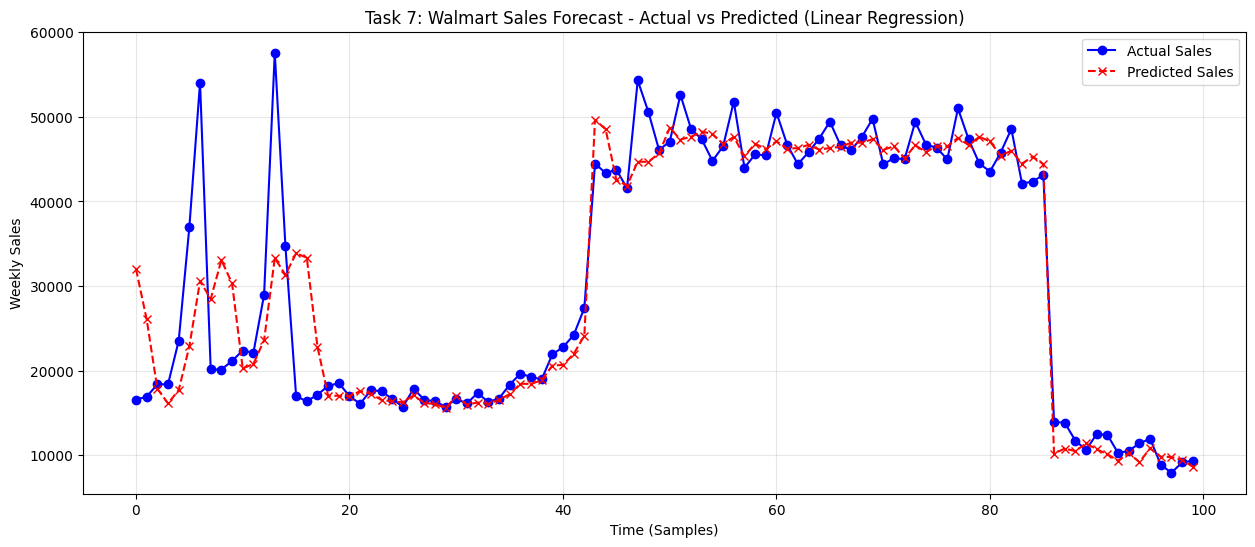

In [45]:
import matplotlib.pyplot as plt

# Visualizing the first 100 predictions to see the trend
plt.figure(figsize=(15, 6))
plt.plot(y_valid.values[:100], label='Actual Sales', color='blue', marker='o')
plt.plot(preds[:100], label='Predicted Sales', color='red', linestyle='--', marker='x')

plt.title('Task 7: Walmart Sales Forecast - Actual vs Predicted (Linear Regression)')
plt.xlabel('Time (Samples)')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
